# FIRST LAB

Lucas Felipe Hernández Palacio

## 1.	Context. 

<div style="text-align: justify;">

La evaluación de la salud del suelo ha evolucionado desde un enfoque centrado en la productividad agrícola hacia una evaluación integrada que considera la biota del suelo y los procesos bióticos que impactan las propiedades edáficas (Zeng et al., 2024). El concepto de "Calidad del Suelo" fue introducido en 1971, seguido por el término "Salud del Suelo" acuñado en 1992. La definición más aceptada por la comunidad científica establece que la salud del suelo es "la capacidad de un suelo para funcionar dentro de los límites del ecosistema y del uso de la tierra para sostener la productividad biológica, mantener la calidad ambiental y promover la salud vegetal y animal" (Norris et al., 2020; Guo, 2021; Doran & Zeiss, 2000; Lehmann et al., 2020; Bünemann et al., 2018).

La espectroscopía se ha consolidado como una herramienta para el monitoreo de indicadores de salud del suelo. Esta técnica se fundamenta en la absorción de radiación electromagnética por enlaces moleculares específicos, donde los grupos funcionales orgánicos e inorgánicos presentan bandas de absorción características (Viscarra Rossel & McBratney, 2010; Stenberg et al., 2010). Permite obtener información cualitativa sobre la composición del suelo, incluyendo minerales de arcilla, óxidos de hierro y materia orgánica, mediante un análisis rápido y no destructivo (Soriano-Disla et al., 2014).

La espectroscopía de infrarrojo medio (MIR, 2500-25000 nm) ha demostrado proporcionar calibraciones superiores al NIR para carbono orgánico del suelo (Reeves, 2010; Janik et al., 2007). Calderón et al. (2022) evaluaron la espectroscopía MIR para la medición de un conjunto extenso de propiedades edáficas, identificando grupos específicos del carbono orgánico. Iniciativas como la Open Soil Spectral Library (OSSL) han compilado información espectral de múltiples fuentes globales, incluyendo ICRAF-ISRIC y LUCAS (Orgiazzi et al., 2018; Tóth et al., 2013), facilitando el desarrollo de modelos predictivos (Viscarra Rossel et al., 2022).

Sin embargo, la transferibilidad de modelos entre instrumentos y regiones geográficas sigue siendo un desafío que requiere técnicas de transferencia de calibración (Safanelli et al., 2025; Hengl et al., 2021). Las principales limitaciones de las mediciones incluyen la variabilidad del contenido de humedad que enmascara señales espectrales, la heterogeneidad superficial del suelo y las condiciones ambientales variables que afectan la repetibilidad (Liu et al., 2002; Roberts & Cozzolino, 2016; Liu et al., 2020).

</div>

## 2.	Data loading and initial visualization

**Nombre:** Soil Spectroscopy for the Global Good (SS4GG) Network

**Link:** https://www.kaggle.com/competitions/ss4gg-hackathon-mir-soil-spectroscopy/data

**Link Google Drive:** https://drive.google.com/file/d/1gdKgdHOxGfeaVUj0OHHFrOneaFbt5o2c/view?usp=sharing
<p align="justify">
Para este laboratorio, se seleccionó un dataset público proveniente de una competencia de hackathon organizada por la red Soil Spectroscopy for the Global Good (SS4GG). Este dataset contiene espectros de infrarrojo medio (MIR) de muestras de suelo, diseñado para desarrollar modelos de predicción de contenido de arcilla que sean robustos ante la variabilidad entre instrumentos.
</p>

<p align="justify">
El dataset está compuesto por dos conjuntos principales de datos:
</p>

*<p align="justify">Conjunto de Entrenamiento (train.csv):*</p>
<p align="justify">
Contiene 57,268 muestras con 1,682 columnas, incluyendo:
</p>

- **dataset:** Proveedor original de la biblioteca espectral
- **id:** Identificador único de la Open Soil Spectral Library (OSSL)
- **clay_perc (%):** Contenido de arcilla
- **sand_perc (%):** Contenido de arena
- **silt_perc (%):** Contenido de limo
- **texture_sum:** Suma de las fracciones texturales (exactamente 100%)
- **Valores espectrales:** Rango de 650-4000 cm⁻¹ con intervalo de 2 cm⁻¹

<p align="justify">
Estas variables representan la textura del suelo, un indicador fundamental de las propiedades físicas e hidráulicas edáficas.
</p>

*<p align="justify">Conjunto de Prueba (test.csv):*</p>
<p align="justify">
Contiene 250 espectros correspondientes a 50 muestras de suelo escaneadas con 5 instrumentos FTIR diferentes:
</p>

- **INST1:** Bruker Alpha
- **INST2:** Perkin Elmer Spectrum 100
- **INST3:** Bruker Invenio
- **INST4:** Thermo Fisher Nicolet
- **INST5:** Agilent 4300

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Carga y visualización del dataset:**

<p align="justify">
El dataset contiene 1,679 columnas: tres columnas de identificación (unique_id, instrument, sample_id) y 1,676 columnas con valores espectrales correspondientes a los números de onda desde 650 hasta 4000 cm⁻¹.
</p>


In [135]:
file_id = '1gdKgdHOxGfeaVUj0OHHFrOneaFbt5o2c'

url = f'https://drive.google.com/uc?id={file_id}&export=download'

soil_spectroscopy = pd.read_csv(url)
soil_spectroscopy.head(5)

,unique_id,instrument,sample_id,650,652,654,656,658,660,662,...,3982,3984,3986,3988,3990,3992,3994,3996,3998,4000
0,U1,INST1,S1139,2.53446,2.52495,2.52004,2.52020,2.52145,2.50962,2.49194,...,1.18839,1.18797,1.18738,1.18698,1.18669,1.18630,1.18579,1.18530,1.18506,1.18525
1,U2,INST1,S1239,2.60417,2.60600,2.60204,2.58584,2.57408,2.57234,2.56945,...,1.27061,1.26969,1.26833,1.26743,1.26721,1.26732,1.26732,1.26700,1.26650,1.26590
2,U3,INST1,S1444,2.42569,2.41961,2.41259,2.40228,2.39089,2.38415,2.37893,...,1.24224,1.24227,1.24214,1.24177,1.24137,1.24112,1.24112,1.24136,1.24177,1.24228
3,U4,INST1,S1484,2.53700,2.52715,2.51345,2.50851,2.51366,2.51775,2.51627,...,1.26346,1.26368,1.26317,1.26224,1.26156,1.26088,1.26004,1.25949,1.25956,1.26061
4,U5,INST1,S1498,2.44423,2.44196,2.42782,2.41031,2.40321,2.40429,2.40328,...,1.27726,1.27669,1.27611,1.27622,1.27664,1.27657,1.27628,1.27609,1.27586,1.27549


**Visualización de tipos de datos:**

<p align="justify">
Se emplea la función type para confirmar que la estructura de datos importada es un DataFrame de pandas. Adicionalmente, el atributo dtypes permite examinar el tipo de dato asignado a cada una de las columnas del conjunto de datos.
</p>

In [136]:
print(type(soil_spectroscopy))
print(soil_spectroscopy.shape)
print(soil_spectroscopy.dtypes)

<class 'pandas.core.frame.DataFrame'>
(250, 1679)
unique_id      object
instrument     object
sample_id      object
650           float64
652           float64
               ...   
3992          float64
3994          float64
3996          float64
3998          float64
4000          float64
Length: 1679, dtype: object


In [137]:
wavenumbers = soil_spectroscopy.columns[3:].astype(float)

print(f"Rango espectral: {wavenumbers.min()} - {wavenumbers.max()} cm⁻¹")

Rango espectral: 650.0 - 4000.0 cm⁻¹


**Visualización de todos los espectros MIR:**

<p align="justify">
Se extraen los valores espectrales del dataset excluyendo las tres primeras columnas de identificación. Posteriormente, se grafican las 250 muestras superpuestas, donde cada línea representa el espectro de una muestra diferente.
</p>


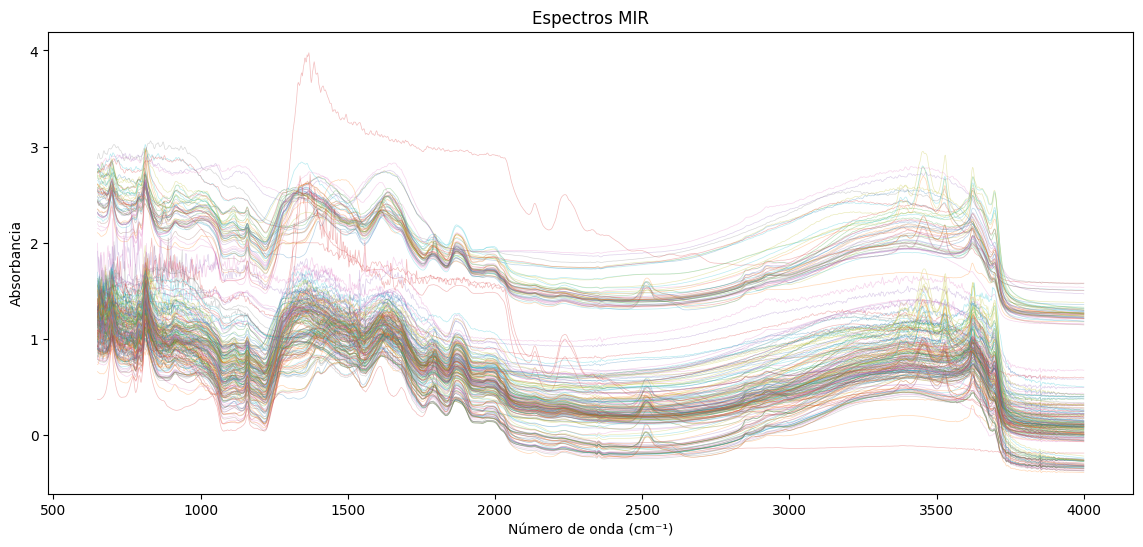

In [138]:
spectra = soil_spectroscopy[soil_spectroscopy.columns[3:]].values

plt.figure(figsize=(14, 6))
for i in range(len(soil_spectroscopy)):
    plt.plot(wavenumbers, spectra[i], alpha=0.3, linewidth=0.5)

plt.xlabel('Número de onda (cm⁻¹)')
plt.ylabel('Absorbancia')
plt.title('Espectros MIR')
plt.show()

In [139]:
print(soil_spectroscopy['instrument'].value_counts())

instrument
INST1    50
INST2    50
INST3    50
INST4    50
INST5    50
Name: count, dtype: int64


**Visualización de espectro individual por instrumento:**

<p align="justify">
Se selecciona una muestra y se extrae su espectro correspondiente a los diferentes instrumentos. Los datos se convierten a un arreglo numpy de tipo float para su graficación. La curva resultante muestra el perfil de absorbancia característico de esa muestra de suelo, con picos y valles que representan las bandas de absorción de los diferentes componentes minerales y orgánicos presentes.
</p>


In [140]:
wavelengths = np.array(soil_spectroscopy.columns[3:]).astype(float)
muestra = soil_spectroscopy['sample_id'].unique()[3]
data_muestra = soil_spectroscopy[soil_spectroscopy['sample_id'] == muestra]

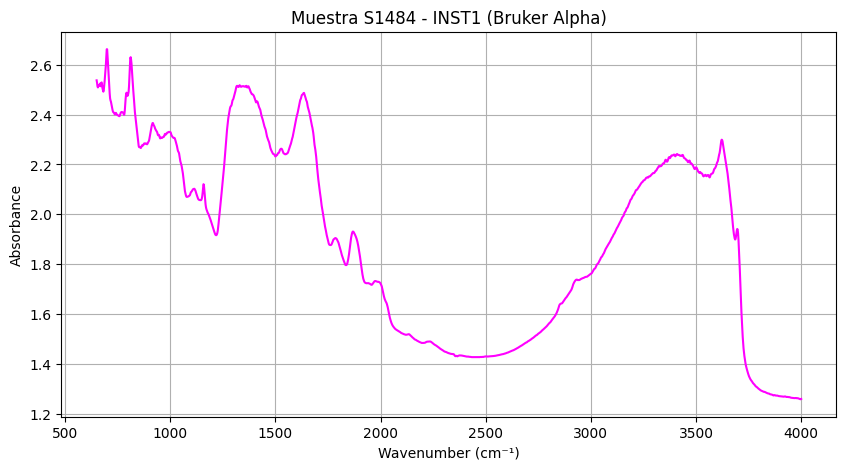

In [141]:
espectro_inst1 = data_muestra[
    data_muestra['instrument'] == 'INST1'].to_numpy()[:, 3:].astype(float)[0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, espectro_inst1, color="magenta")
plt.title(f"Muestra {muestra} - INST1 (Bruker Alpha)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

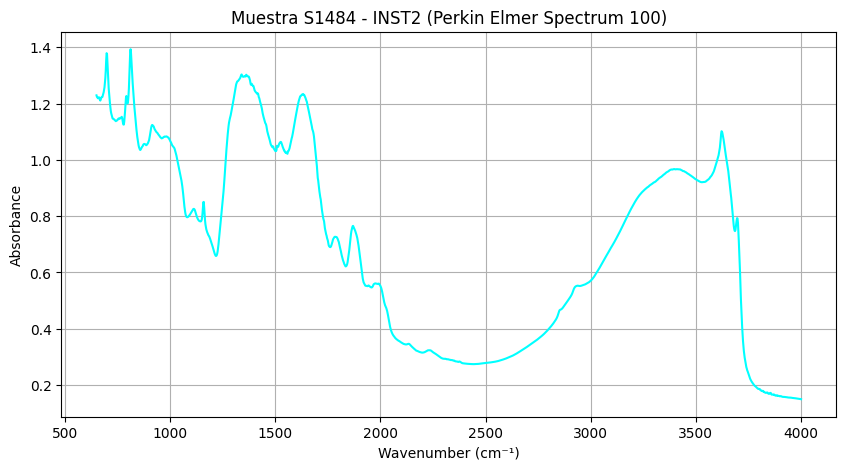

In [142]:
espectro_inst2 = data_muestra[
    data_muestra['instrument'] == 'INST2'].to_numpy()[:, 3:].astype(float)[0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, espectro_inst2, color="cyan")
plt.title(f"Muestra {muestra} - INST2 (Perkin Elmer Spectrum 100)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

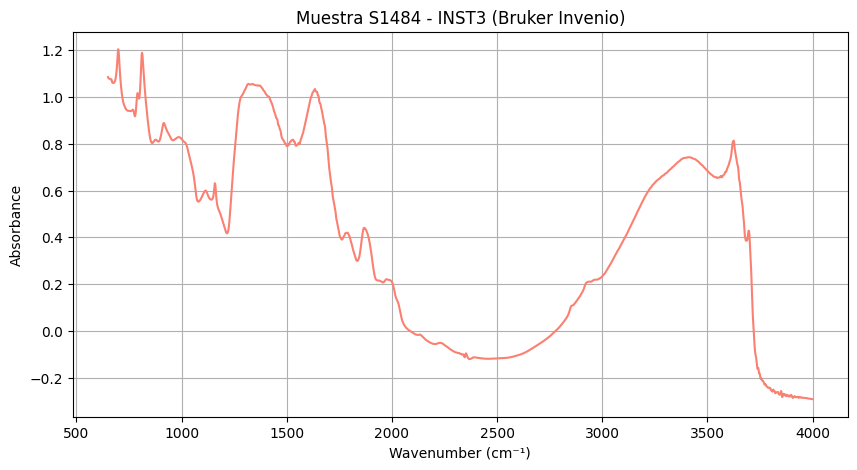

In [143]:
espectro_inst3 = data_muestra[
    data_muestra['instrument'] == 'INST3'].to_numpy()[:, 3:].astype(float)[0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, espectro_inst3, color="salmon")
plt.title(f"Muestra {muestra} - INST3 (Bruker Invenio)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

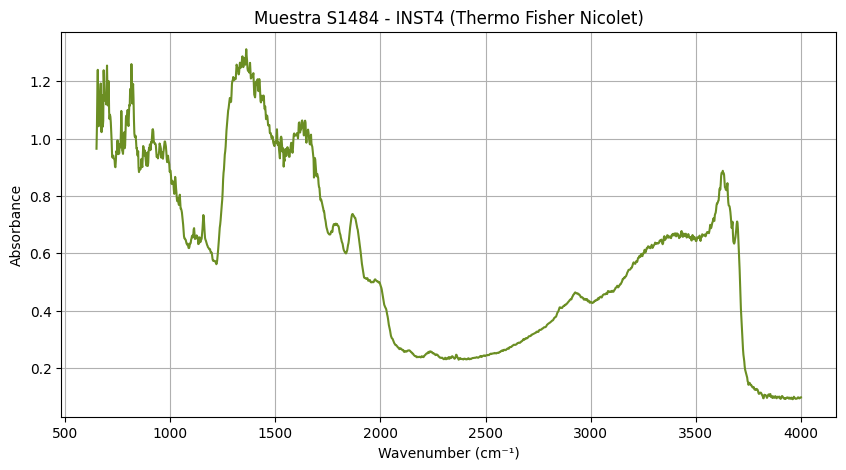

In [144]:
espectro_inst4 = data_muestra[
    data_muestra['instrument'] == 'INST4'].to_numpy()[:, 3:].astype(float)[0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, espectro_inst4, color="olivedrab")
plt.title(f"Muestra {muestra} - INST4 (Thermo Fisher Nicolet)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

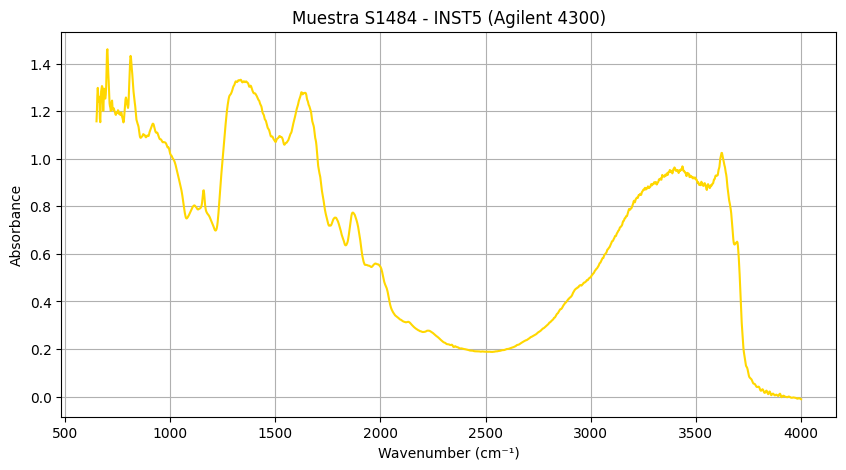

In [145]:
espectro_inst5 = data_muestra[
    data_muestra['instrument'] == 'INST5'].to_numpy()[:, 3:].astype(float)[0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, espectro_inst5, color="gold")
plt.title(f"Muestra {muestra} - INST5 (Agilent 4300)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

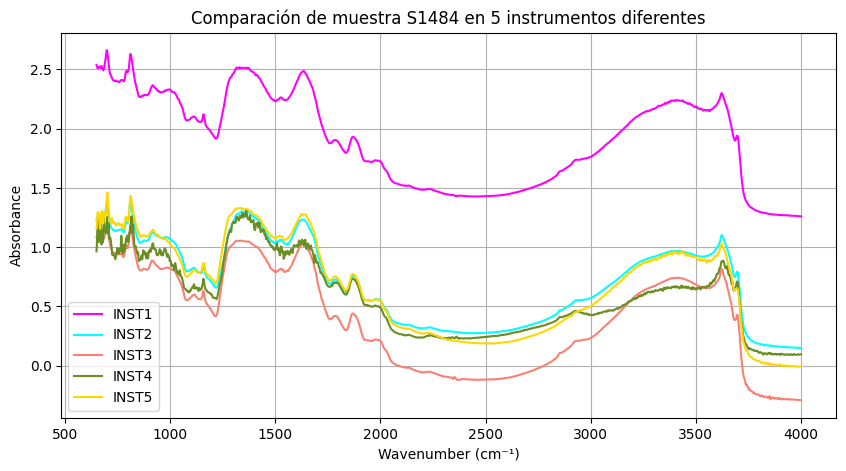

In [146]:
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, espectro_inst1, color="magenta", label="INST1")
plt.plot(wavelengths, espectro_inst2, color="cyan", label="INST2")
plt.plot(wavelengths, espectro_inst3, color="salmon", label="INST3")
plt.plot(wavelengths, espectro_inst4, color="olivedrab", label="INST4")
plt.plot(wavelengths, espectro_inst5, color="gold", label="INST5")
plt.title(f"Comparación de muestra {muestra} en 5 instrumentos diferentes")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend()
plt.grid(True)
plt.show()

## 3.	OOP for data processing. 

**Primera clase:**

<p align="justify">
Para definir los atributos de la clase SoilSpectraProcessor, se utiliza el arreglo "wavelengths" que contiene los números de onda, y se extraen todas las filas con los valores de absorbancia almacenándolas en la variable spectra.
</p>

In [147]:
spectra = data_muestra.to_numpy()[:, 3:].astype(float)
print(spectra)
print(type(spectra))

[[ 2.537    2.52715  2.51345 ...  1.25949  1.25956  1.26061]
 [ 1.22948  1.22418  1.22182 ...  0.15026  0.15004  0.14962]
 [ 1.08422  1.08018  1.0784  ... -0.29043 -0.29075 -0.29094]
 [ 0.96473  1.03998  1.16071 ...  0.09646  0.09657  0.09671]
 [ 1.1571   1.20174  1.26501 ... -0.00853 -0.00975 -0.01082]]
<class 'numpy.ndarray'>


**Métodos de la clase SoilSpectraProcessor:**

<p align="justify">
El primer método (además del constructor) es el suavizado por promedio móvil (moving_average). Esto se implementa porque los datos adquiridos con espectrómetros FTIR pueden presentar ruido, especialmente en ciertas regiones del espectro donde se generan picos debido a la concentración de componentes del suelo. El suavizado permite obtener curvas más estables y comparables sin perder información de los picos característicos.
</p>

<p align="justify">
El segundo método es la normalización por área (normalize_area), con el propósito de hacer todos los espectros comparables entre sí. Por ejemplo, una muestra puede tener un pico a 1000 cm⁻¹ con un valor de 0.8, mientras que otra tiene un valor de 0.3. Aunque la forma espectral sea similar, la diferencia en altura puede dar la impresión de que son distintas. Con la normalización, ambas curvas se escalan a un área total de 1, y la comparación se enfoca en la forma del espectro (picos y bandas), no en la magnitud de los valores originales.
</p>

<p align="justify">
El tercer método calcula el área bajo la curva en rangos específicos (calculate_band_area). Este enfoque se implementa porque ciertos rangos espectrales tienen correlación directa con componentes específicos del suelo. Por ejemplo, el rango 1000-1200 cm⁻¹ está asociado con minerales arcillosos (enlaces Si-O), mientras que el rango 1350-1450 cm⁻¹ se relaciona con materia orgánica (enlaces C-H). Integrar el área bajo la curva en estos intervalos resume la información espectral en un valor cuantitativo único, facilitando la comparación entre muestras y permitiendo correlacionar estos valores con la presencia de componentes edáficos.
</p>

In [127]:
class SoilSpectraProcessor:

    def __init__(self, wavelengths, spectra):
        self.wavelengths = wavelengths
        self.spectra = spectra

    def moving_average(self, window):
        kernel = np.ones(window) / window
        smoothed = np.array([
            np.convolve(row, kernel, mode="same") for row in self.spectra])
        self.spectra = smoothed
        return self

    def normalize_area(self):
        areas = np.trapezoid(self.spectra, x=self.wavelengths, axis=1)
        for i in range(len(areas)):
            a = areas[i]
            if a == 0:
                a = 1e-9
            self.spectra[i] = self.spectra[i] / a
        return self

    def calculate_band_area(self, initial_cm, end_cm):
        mask = (self.wavelengths >= initial_cm) & (self.wavelengths <= end_cm)
        band_areas = np.trapezoid(self.spectra[:, mask], x=self.wavelengths[mask], axis=1)
        return band_areas


*Explicación de las funciones:*

<p align="justify">
<strong>convolve:</strong> Esta técnica de suavizado utiliza un filtro de promedio móvil implementado en NumPy. Se crea un kernel específico que posteriormente se aplica sobre cada espectro mediante la función convolve(). El resultado es que cada punto se sustituye por el promedio de los puntos adyacentes según el tamaño de ventana definido. Se configura el modo en 'same' para asegurar que el espectro procesado conserve el número original de puntos, manteniendo así sus dimensiones intactas.
</p>

<p align="justify">
<strong>trapezoid:</strong> Se emplea la función trapezoid de NumPy para realizar la integración numérica del conjunto de datos aplicando la regla trapezoidal. En este contexto, dicha función se ejecuta sobre cada espectro con el objetivo de determinar el área bajo la curva de absorbancia respecto al número de onda.
</p>

<p align="justify">
En el tercer método, se recurre igualmente a np.trapezoid para obtener el área bajo la curva mediante la regla trapezoidal. Esta implementación permite definir un intervalo específico de números de onda (delimitado por initial_cm y end_cm), devolviendo un único valor que corresponde al área contenida en dicha región espectral.
</p>

In [128]:
soil_proc = SoilSpectraProcessor(wavelengths, spectra)

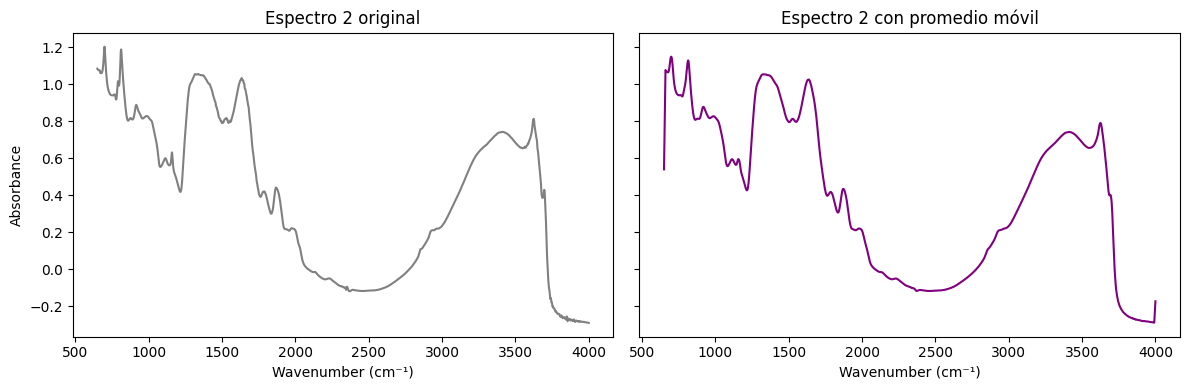

In [129]:
spectra_original = spectra.copy()

soil_proc.moving_average(window=10)

muestra = 2
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(wavelengths, spectra_original[muestra], color="gray")
axs[0].set_title(f"Espectro {muestra} original")
axs[0].set_xlabel("Wavenumber (cm⁻¹)")
axs[0].set_ylabel("Absorbance")

axs[1].plot(wavelengths, soil_proc.spectra[muestra], color="purple")
axs[1].set_title(f"Espectro {muestra} con promedio móvil")
axs[1].set_xlabel("Wavenumber (cm⁻¹)")

plt.tight_layout()
plt.show()

**Comparación del espectro original y suavizado:**

<p align="justify">
La figura muestra una comparación lado a lado del espectro de la muestra 2 antes y después de aplicar el método de suavizado por promedio móvil. El panel izquierdo presenta el espectro original con sus variaciones y ruido característico, mientras que el panel derecho muestra el mismo espectro después del procesamiento con una ventana de suavizado. Se observa que la curva suavizada mantiene los picos y bandas de absorción principales, pero con una reducción notable del ruido, resultando en un perfil espectral más limpio y fácil de interpretar.
</p>

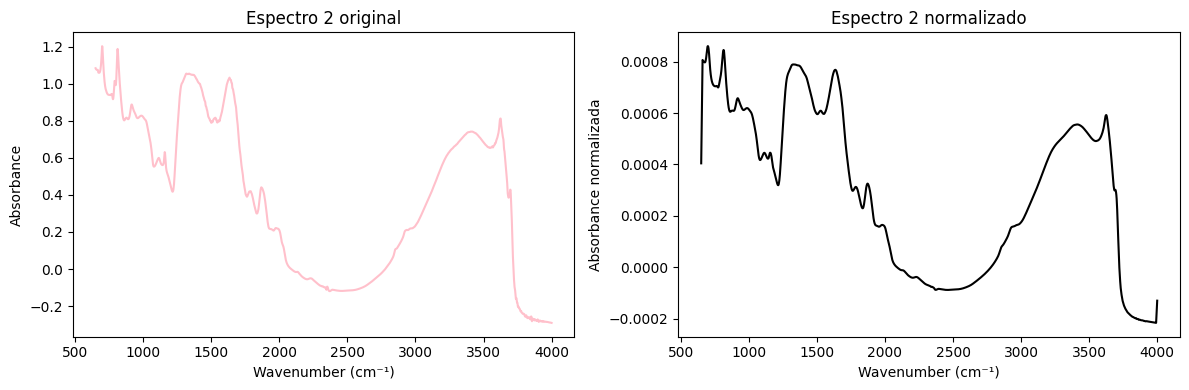

In [130]:
soil_proc.normalize_area()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(wavelengths, spectra_original[muestra], color="pink")
axs[0].set_title(f"Espectro {muestra} original")
axs[0].set_xlabel("Wavenumber (cm⁻¹)")
axs[0].set_ylabel("Absorbance")

axs[1].plot(wavelengths, soil_proc.spectra[muestra], color="black")
axs[1].set_title(f"Espectro {muestra} normalizado")
axs[1].set_xlabel("Wavenumber (cm⁻¹)")
axs[1].set_ylabel("Absorbance normalizada")

plt.tight_layout()
plt.show()

**Comparación del espectro original y normalizado:**

<p align="justify">
La figura presenta una comparación entre el espectro original de la muestra 2 y su versión normalizada por área. El panel izquierdo muestra el espectro con sus valores de absorbancia originales (rango aproximado de -0.2 a 1.2), mientras que el panel derecho exhibe el espectro después de la normalización, donde los valores se han escalado a un área total de 1 (rango aproximado de -0.0002 a 0.0010). Se observa que la forma espectral se conserva, manteniendo los mismos picos y bandas de absorción, pero con una escala diferente que permite comparaciones directas entre muestras independientemente de sus magnitudes originales.
</p>

Área bajo la curva de 1000 a 1200 cm⁻¹: 0.09329755917387182
Área bajo la curva de 1350 a 1450 cm⁻¹: 0.07551426372316483


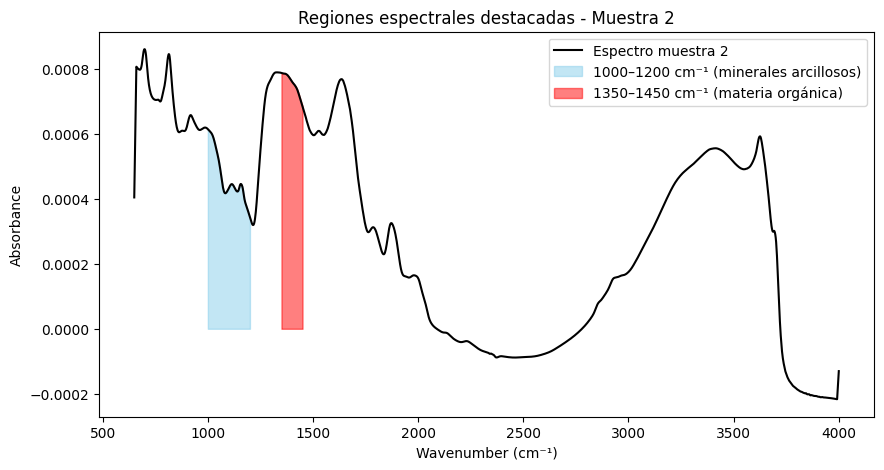

In [131]:
band_area_one = soil_proc.calculate_band_area(1000, 1200)[muestra]
band_area_two = soil_proc.calculate_band_area(1350, 1450)[muestra]
print(f"Área bajo la curva de 1000 a 1200 cm⁻¹: {band_area_one}")
print(f"Área bajo la curva de 1350 a 1450 cm⁻¹: {band_area_two}")

cm_minerales = (wavelengths >= 1000) & (wavelengths <= 1200)
cm_organica = (wavelengths >= 1350) & (wavelengths <= 1450)

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, soil_proc.spectra[muestra], 
         color="black", label=f"Espectro muestra {muestra}")
plt.fill_between(wavelengths[cm_minerales], soil_proc.spectra[muestra][cm_minerales],
                 color="skyblue", alpha=0.5, 
                 label="1000–1200 cm⁻¹ (minerales arcillosos)")
plt.fill_between(wavelengths[cm_organica], soil_proc.spectra[muestra][cm_organica],
                 color="red", alpha=0.5, 
                 label="1350–1450 cm⁻¹ (materia orgánica)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title(f"Regiones espectrales destacadas - Muestra {muestra}")
plt.legend()
plt.show()

**Cálculo del área bajo la curva en regiones espectrales específicas:**

<p align="justify">
La figura ilustra el espectro normalizado de la muestra 2 con dos regiones espectrales destacadas mediante sombreado. La región azul (1000-1200 cm⁻¹) corresponde a bandas de absorción asociadas con minerales arcillosos (enlaces Si-O), con un área calculada de 0.1087. La región rosa (1350-1450 cm⁻¹) representa bandas relacionadas con materia orgánica (enlaces C-H), con un área de 0.0614. Estos valores cuantitativos permiten caracterizar la composición del suelo y facilitan la comparación entre diferentes muestras mediante indicadores numéricos derivados del espectro.
</p>

## 4.	Numerical derivation or integration of data. 

<p align="justify">
Para este análisis se empleó un conjunto de datos de espectroscopía de suelos, donde se calculó la derivada del espectro de absorbancia con respecto al número de onda. El objetivo es detectar con mayor exactitud los puntos máximos y mínimos dentro de la señal, correspondientes a los picos y valles espectrales. Mediante esta técnica se logran identificar las variaciones más pronunciadas en la pendiente de la curva, lo que facilita ubicar con precisión las bandas de absorción características. Esto permite reconocer los intervalos de números de onda asociados a los distintos componentes minerales y orgánicos presentes en las muestras de suelo.
</p>

<p align="justify">
Con el fin de transformar los datos discretos del espectro en una función continua, se creó la función f_spectrum(x). Para ello se utilizó np.interp, que ejecuta una interpolación lineal entre los valores de número de onda y sus correspondientes absorbancias, haciendo posible la estimación de valores en puntos intermedios. Además, se establecieron valores fijos en los límites del espectro para que, al evaluar la función fuera del rango de medición, se devuelva el valor del extremo más próximo evitando así errores por extrapolación.
</p>

In [91]:
def f_spectrum(x):
    return np.interp(x, wavelengths, spectra_original[muestra], left=spectra_original[muestra][0], right=spectra_original[muestra][-1])

print(spectra_original[muestra][0])
print(spectra_original[muestra][-1])

1.19298
-0.30462


In [92]:
class Derivative:
    def __init__(self, func, h=1e-5):
        self.f = func
        self.h = h
    
    def __call__(self, x):
        return (self.f(x + self.h) - self.f(x)) / self.h


class Der2central(Derivative):
    def __call__(self, x):
        return (self.f(x + self.h) - self.f(x - self.h)) / (2 * self.h)

**Cálculo del paso de incremento y evaluación de la derivada:**

<p align="justify">
El valor del incremento h se calculó promediando las diferencias entre números de onda consecutivos del conjunto de datos, empleando la función diff para determinar estas diferencias y mean para obtener su promedio. A continuación, se creó una instancia de la clase Der2central utilizando la función espectral f_spectrum junto con el paso h previamente calculado. Por último, se evaluó la derivada en cada punto del vector de números de onda, obteniendo como resultado el arreglo derivate_absorbance. Dicho arreglo contiene la variación de la absorbancia con respecto al número de onda para cada posición del espectro.
</p>

In [93]:
h = np.mean(np.diff(wavelengths))
df = Der2central(f_spectrum, h=h)
derivate_absorbance = df(wavelengths)

Los valores numéricos derivados de la muestra 2 son: [-4.3750e-04 -9.1500e-04 -1.3275e-03 ... -2.4500e-04 -1.7250e-04
 -7.0000e-05]


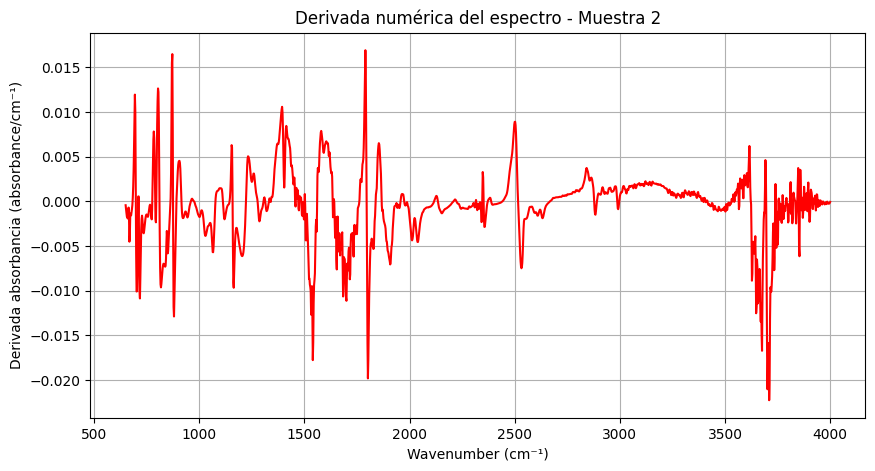

In [94]:
print(f"Los valores numéricos derivados de la muestra {muestra} son: {derivate_absorbance}")

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, derivate_absorbance, color="red")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Derivada absorbancia (absorbance/cm⁻¹)")
plt.title(f"Derivada numérica del espectro - Muestra {muestra}")
plt.grid(True)
plt.show()

<p align="justify">
El vector presentado contiene los valores de la derivada numérica de la absorbancia respecto al número de onda para la muestra 2. Cada valor representa la pendiente del espectro: los números positivos indican un incremento en la absorbancia, los valores negativos reflejan una disminución, y los valores cercanos a cero corresponden a regiones estables sin cambios significativos.
</p>

<p align="justify">
Estas variaciones se visualizan en la gráfica. Se observa que los cambios más abruptos ocurren en la región entre 700 y 1800 cm⁻¹, lo cual puede corresponder a las bandas de absorción de minerales arcillosos y materia orgánica identificadas previamente. A medida que el número de onda aumenta hacia la región de 2000-3500 cm⁻¹, la derivada tiende a estabilizarse cerca de cero, indicando que la señal espectral se vuelve más uniforme y carece de variaciones marcadas. En la región de 3500-4000 cm⁻¹ se observan nuevamente cambios pronunciados, sugiriendo la presencia de bandas de absorción asociadas a grupos funcionales específicos del suelo.
</p>

## 5.	Matrix operations. 

In [97]:
print(type(wavelengths))
print(type(spectra))
print(f'The following vector shows the wavelengths are:\n {wavelengths}')
print(f'\nThe following matrix shows the absorbance values: {spectra}')
print(spectra.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
The following vector shows the wavelengths are:
 [ 650.  652.  654. ... 3996. 3998. 4000.]

The following matrix shows the absorbance values: [[ 2.60417  2.606    2.60204 ...  1.267    1.2665   1.2659 ]
 [ 1.27236  1.27232  1.2673  ...  0.06974  0.06936  0.06898]
 [ 1.19298  1.19123  1.18932 ... -0.30393 -0.30434 -0.30462]
 [ 1.09278  1.06651  1.08965 ...  0.06696  0.06898  0.06997]
 [ 1.55722  1.46793  1.48982 ...  0.01101  0.01121  0.01106]]
(5, 1676)


**Extracción de matriz espectral en un rango específico:**

<p align="justify">
Primero se verifica si las dimensiones del arreglo de espectros coinciden con el vector de números de onda. Si no coinciden, se transpone la matriz para alinear correctamente filas y columnas; de lo contrario, se mantiene la matriz original. Posteriormente, se crea una máscara booleana para seleccionar únicamente los números de onda dentro del rango 1000-1500 cm⁻¹. Esta máscara se aplica a la matriz de absorbancia para extraer solo las columnas correspondientes a dicho intervalo espectral, almacenando el resultado en extract_wave_ranges. Finalmente, se imprime el tamaño de la matriz extraída y sus primeros 5 valores para verificar la operación.
</p>

In [98]:
if spectra.shape[0] != wavelengths.shape[0]:
    matrix_absorbance = spectra.T
else:
    matrix_absorbance = spectra

mask = (wavelengths >= 1000) & (wavelengths <= 1500)
extract_wave_ranges = matrix_absorbance[mask, :]

print("Tamaño de la matriz extraída en el rango 1000-1500 cm⁻¹:", extract_wave_ranges.shape)
print("Primeros 5 valores de la matriz extraída:\n", extract_wave_ranges[:5, :5])

Tamaño de la matriz extraída en el rango 1000-1500 cm⁻¹: (251, 5)
Primeros 5 valores de la matriz extraída:
 [[2.37635 1.09418 0.83368 0.81404 1.18012]
 [2.37274 1.09306 0.83014 0.79733 1.17871]
 [2.36817 1.09098 0.82668 0.76978 1.175  ]
 [2.36675 1.08866 0.82358 0.77772 1.16991]
 [2.36957 1.08566 0.82101 0.79202 1.16427]]


In [ ]:
extract_wave_ranges_centered = extract_wave_ranges - extract_wave_ranges.mean(
    axis=0, keepdims=True)

print("Tamaño de la matriz centrada:", extract_wave_ranges_centered.shape)
print("Primeros 5 valores de la matriz centrada:\n", extract_wave_ranges_centered[
    :5, :5])

Tamaño de la matriz centrada: (251, 5)
Primeros 5 valores de la matriz centrada:
 [[ 0.15273498  0.15392112  0.16617359  0.01030689  0.17472231]
 [ 0.14912498  0.15280112  0.16263359 -0.00640311  0.17331231]
 [ 0.14455498  0.15072112  0.15917359 -0.03395311  0.16960231]
 [ 0.14313498  0.14840112  0.15607359 -0.02601311  0.16451231]
 [ 0.14595498  0.14540112  0.15350359 -0.01171311  0.15887231]]


## Discussion section and conclusions 

### Conclusions

## References
Bünemann, E. K., Bongiorno, G., Bai, Z., Creamer, R. E., De Deyn, G., de Goede, R., Fleskens, L., Geissen, V., Kuyper, T. W., Mäder, P., Pulleman, M., Sukkel, W., van Groenigen, J. W., & Brussaard, L. (2018). Soil quality – A critical review. Soil Biology and Biochemistry, 120, 105–125. https://doi.org/10.1016/j.soilbio.2018.01.030

Calderón, F. J., et al. (2022). Mid-infrared spectroscopy for accurate measurement of an extensive set of soil properties for assessing soil functions. Soil Security, 6, 100043. https://doi.org/10.1016/j.soisec.2022.100043

Doran, J. W., & Zeiss, M. R. (2000). Soil health and sustainability: managing the biotic component of soil quality. Applied Soil Ecology, 15(1), 3–11. https://doi.org/10.1016/S0929-1393(00)00067-6

Guo, M. (2021). Soil Health Assessment and Management: Recent Development in Science and Practices. Soil Systems, 5(4), 61. https://doi.org/10.3390/soilsystems5040061

Hengl, T., et al. (2021). African soil properties and nutrients mapped at 30 m spatial resolution using two-scale ensemble machine learning. Scientific Reports, 11, 6130. https://doi.org/10.1038/s41598-021-85639-y

Janik, L. J., Skjemstad, J. O., Shepherd, K. D., & Spouncer, L. R. (2007). The prediction of soil carbon fractions using mid-infrared-partial least square analysis. Australian Journal of Soil Research, 45(2), 73–81. https://doi.org/10.1071/SR06083

Lehmann, J., Bossio, D. A., Kögel-Knabner, I., & Rillig, M. C. (2020). The concept and future prospects of soil health. Nature Reviews Earth & Environment, 1(10), 544–553. https://doi.org/10.1038/s43017-020-0080-8

Liu, J., et al. (2020). Soil Moisture Estimate Uncertainties from the Effect of Soil Texture on Dielectric Semiempirical Models. Remote Sensing, 12(14), 2343. https://doi.org/10.3390/rs12142343

Liu, W., Baret, F., Gu, X., Tong, Q., Zheng, L., & Zhang, B. (2002). Relating soil surface moisture to reflectance. Remote Sensing of Environment, 81(2-3), 238–246. https://doi.org/10.1016/S0034-4257(01)00347-9

Norris, C. E., Bean, G. M., Cappellazzi, S. B., Cope, M., Greub, K. L. H., Liptzin, D., Rieke, E. L., Tracy, P. W., Morgan, C. L. S., & Honeycutt, C. W. (2020). Introducing the North American project to evaluate soil health measurements. Agronomy Journal, 112(4), 3195–3215. https://doi.org/10.1002/agj2.20234

Orgiazzi, A., Ballabio, C., Panagos, P., Jones, A., & Fernández-Ugalde, O. (2018). LUCAS Soil, the largest expandable soil dataset for Europe: a review. European Journal of Soil Science, 69(1), 140–153. https://doi.org/10.1111/ejss.12499

Reeves, J. B. (2010). Near- versus mid-infrared diffuse reflectance spectroscopy for soil analysis emphasizing carbon and laboratory versus on-site analysis. Geoderma, 158(1-2), 3–14. https://doi.org/10.1016/j.geoderma.2009.04.005

Roberts, J. J., & Cozzolino, D. (2016). Wet or dry? The effect of sample characteristics on near infrared spectroscopy of soils. TrAC Trends in Analytical Chemistry, 83, 25–30. https://doi.org/10.1016/j.trac.2016.08.002

Safanelli, J. L., et al. (2025). Open Soil Spectral Library (OSSL): Building reproducible soil calibration models. PLoS ONE, 20(1), e0296545. https://doi.org/10.1371/journal.pone.0296545

Soriano-Disla, J. M., Janik, L. J., Viscarra Rossel, R. A., Macdonald, L. M., & McLaughlin, M. J. (2014). The Performance of Visible, Near-, and Mid-Infrared Reflectance Spectroscopy for Prediction of Soil Physical, Chemical, and Biological Properties. Applied Spectroscopy Reviews, 49(2), 139–186. https://doi.org/10.1080/05704928.2013.811081

Stenberg, B., Viscarra Rossel, R. A., Mouazen, A. M., & Wetterlind, J. (2010). Visible and Near Infrared Spectroscopy in Soil Science. Advances in Agronomy, 107, 163–215. https://doi.org/10.1016/S0065-2113(10)07005-7

Tóth, G., Jones, A., & Montanarella, L. (2013). The LUCAS topsoil database and derived information on the regional variability of cropland topsoil properties in the European Union. Environmental Monitoring and Assessment, 185(9), 7409–7425. https://doi.org/10.1007/s10661-013-3109-3

Viscarra Rossel, R. A., & McBratney, A. B. (2010). Diffuse Reflectance Spectroscopy for High-Resolution Soil Sensing. In Proximal Soil Sensing (pp. 29–47). Springer. https://doi.org/10.1007/978-90-481-8859-8_3

Viscarra Rossel, R. A., et al. (2022). A global soil spectral calibration library and estimation service. Soil Security, 7, 100061. https://doi.org/10.1016/j.soisec.2022.100061

Zeng, Y., Verhoef, A., Vereecken, H., Ben-Dor, E., Veldkamp, T., Shaw, L., Wang, Y., & Su, Z. B. (2024). Tracking Soil Health: Monitoring and Modeling the Soil-Plant System. Authorea Preprints. https://doi.org/10.22541/essoar.171804479.91646868/v1